# Task 4 – Real-World Data Project

## Smart City Public Safety and Emergency Response Analytics

This project applies Data Science techniques to a real-world public safety scenario.
The objective is to analyze historical incident data, identify important patterns, understand emergency response behavior, and use machine learning predictions to support public safety decision-making.

### Project Goals

- Analyze public safety incidents
- Identify high-risk incident patterns
- Study emergency response times
- Analyze severity and emergency levels
- Apply the trained machine learning model
- Generate practical insights and recommendations
- Demonstrate an end-to-end Data Science workflow

## 1. Business Problem

Smart cities generate large amounts of public safety information from incidents and emergency response activities.
Without systematic analysis, it can be difficult to identify high-risk incident patterns, understand affected areas, and support efficient emergency response planning.
This project uses historical public safety incident data to generate data-driven insights that can assist authorities in monitoring incidents and planning emergency resources.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The cleaned dataset prepared during the earlier stages of the project is used for the real-world analysis.
Using the cleaned dataset ensures that the analysis is performed on consistent and validated data.

In [19]:
df = pd.read_csv("../data/smart_city_thiranex_cleaned.csv")

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully.
Rows: 10000
Columns: 15


,Incident_ID,Incident_Type,Area,Time_of_Day,Day_of_Week,Weather,Crowd_Level,CCTV_Available,Police_Response_Time,Ambulance_Response_Time,Fire_Response_Time,Number_of_People,Severity_Score,Previous_Incidents,Emergency_Level
0,1,Theft,Central,Morning,Friday,Rainy,Low,Yes,10.0,12,12,13,2,8,Medium
1,2,Medical,South,Night,Tuesday,Rainy,High,No,19.0,24,5,112,2,7,Medium
2,3,Accident,South,Afternoon,Sunday,Rainy,Low,Yes,25.0,18,25,389,1,5,Medium
3,4,Theft,West,Morning,Thursday,Sunny,High,No,14.0,24,20,50,7,11,High
4,5,Theft,South,Evening,Monday,Sunny,Low,No,21.0,11,8,454,10,11,High


## 3. Dataset Information

The dataset contains historical public safety incident information.
The main variables include incident type, area, time of day, weather, crowd level, emergency response times, severity score, previous incidents, and emergency level.

In [20]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (10000, 15)

Columns:
['Incident_ID', 'Incident_Type', 'Area', 'Time_of_Day', 'Day_of_Week', 'Weather', 'Crowd_Level', 'CCTV_Available', 'Police_Response_Time', 'Ambulance_Response_Time', 'Fire_Response_Time', 'Number_of_People', 'Severity_Score', 'Previous_Incidents', 'Emergency_Level']

Data Types:
Incident_ID                  int64
Incident_Type                  str
Area                           str
Time_of_Day                    str
Day_of_Week                    str
Weather                        str
Crowd_Level                    str
CCTV_Available                 str
Police_Response_Time       float64
Ambulance_Response_Time      int64
Fire_Response_Time           int64
Number_of_People             int64
Severity_Score               int64
Previous_Incidents           int64
Emergency_Level                str
dtype: object


## 4. Data Quality Check

The dataset is checked for missing values and duplicate records before performing the real-world analysis.

In [21]:
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Records:", df.duplicated().sum())

if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("\nData quality check passed.")
else:
    print("\nFurther data cleaning may be required.")

Total Missing Values: 0
Total Duplicate Records: 0

Data quality check passed.


## 5. Emergency Situation Overview

The distribution of emergency levels is analyzed to understand the overall public safety situation represented by the dataset.

Emergency Level Counts:


Emergency_Level
High      7525
Medium    1977
Low        498
Name: count, dtype: int64

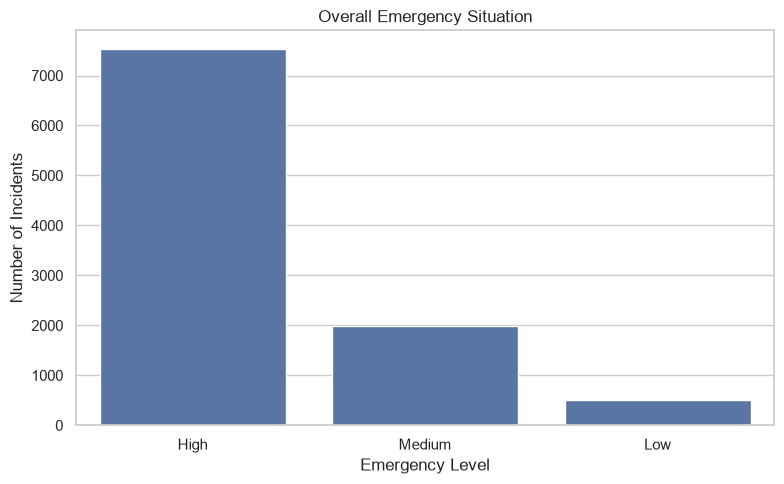

In [22]:
emergency_counts = df["Emergency_Level"].value_counts()

print("Emergency Level Counts:")
display(emergency_counts)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=emergency_counts.index,
    y=emergency_counts.values
)

plt.title("Overall Emergency Situation")
plt.xlabel("Emergency Level")
plt.ylabel("Number of Incidents")
plt.tight_layout()

plt.savefig("../visualizations/task4_emergency_overview.png", dpi=300)
plt.show()

## 6. Incident Risk Analysis

Incident types are analyzed according to their emergency levels.
This helps identify which incident categories require greater attention from public safety authorities.

Emergency_Level,High,Low,Medium
Incident_Type,,,
Accident,1448,101,416
Assault,1485,101,404
Fire,1544,95,383
Medical,1509,99,368
Theft,1539,102,406


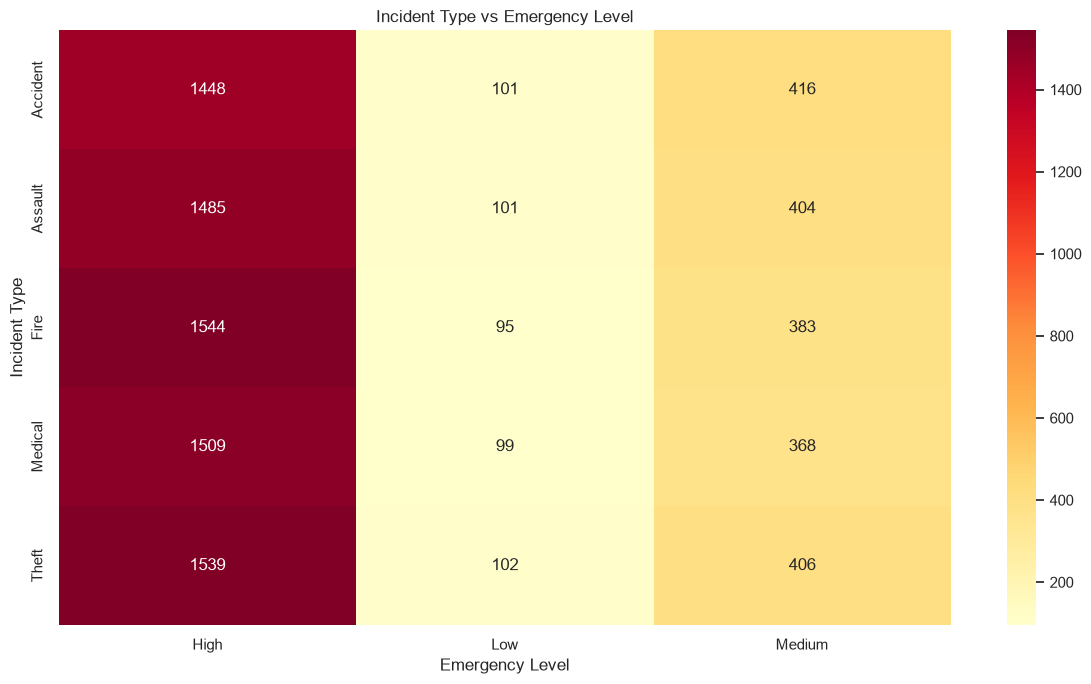

In [23]:
risk_table = pd.crosstab(
    df["Incident_Type"],
    df["Emergency_Level"]
)

display(risk_table)

plt.figure(figsize=(12, 7))

sns.heatmap(
    risk_table,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Incident Type vs Emergency Level")
plt.xlabel("Emergency Level")
plt.ylabel("Incident Type")
plt.tight_layout()

plt.savefig("../visualizations/task4_incident_risk.png", dpi=300)
plt.show()

## 7. Area Risk Analysis

The number of incidents and emergency levels are analyzed across different areas.
This can help identify locations that may require increased monitoring or emergency preparedness.

Emergency_Level,High,Low,Medium
Area,,,
Central,1513,106,402
East,1553,97,393
North,1499,98,379
South,1489,98,381
West,1471,99,422


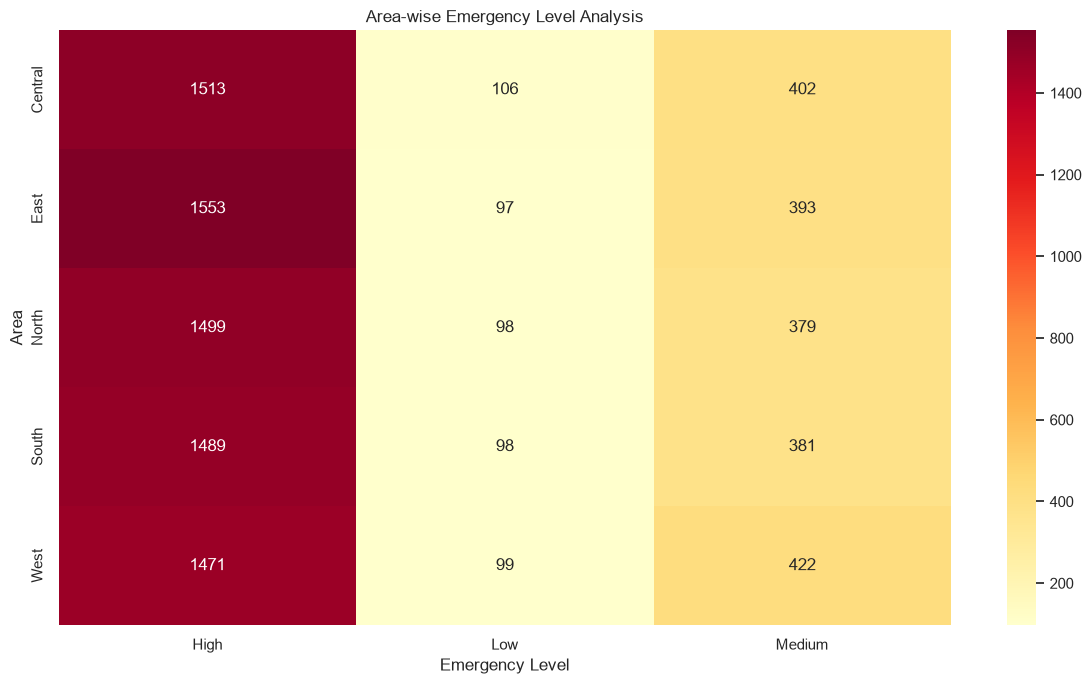

In [24]:
area_risk = pd.crosstab(
    df["Area"],
    df["Emergency_Level"]
)

display(area_risk)

plt.figure(figsize=(12, 7))

sns.heatmap(
    area_risk,
    annot=True,
    fmt="d",
    cmap="YlOrRd"
)

plt.title("Area-wise Emergency Level Analysis")
plt.xlabel("Emergency Level")
plt.ylabel("Area")
plt.tight_layout()

plt.savefig("../visualizations/task4_area_risk.png", dpi=300)
plt.show()

## 8. Severity Analysis

Severity Score is analyzed to understand the seriousness of incidents.
Comparing severity scores across emergency levels can help validate whether the emergency classification follows the expected severity pattern.

,count,mean,median,min,max
Emergency_Level,,,,,
High,7525,6.290498,7.0,1,10
Low,498,1.722892,2.0,1,5
Medium,1977,3.265048,3.0,1,9


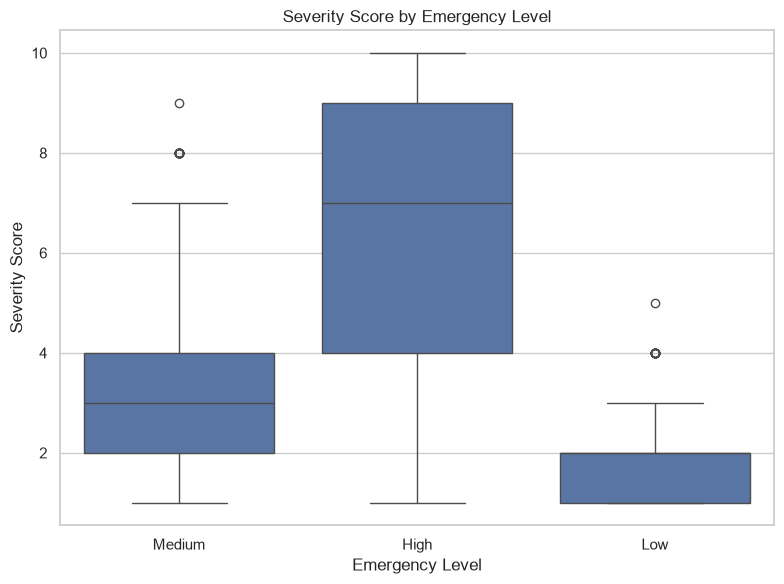

In [25]:
severity_summary = df.groupby(
    "Emergency_Level"
)["Severity_Score"].agg(
    ["count", "mean", "median", "min", "max"]
)

display(severity_summary)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Emergency_Level",
    y="Severity_Score"
)

plt.title("Severity Score by Emergency Level")
plt.xlabel("Emergency Level")
plt.ylabel("Severity Score")
plt.tight_layout()

plt.savefig("../visualizations/task4_severity_analysis.png", dpi=300)
plt.show()

## 9. Emergency Response Analysis

Police, ambulance, and fire response times are analyzed to understand emergency service performance.
Lower response times generally indicate faster emergency response, while higher response times may indicate situations that require further operational investigation.

In [26]:
response_columns = [
    "Police_Response_Time",
    "Ambulance_Response_Time",
    "Fire_Response_Time"
]

response_summary = df[response_columns].describe()

display(response_summary)

,Police_Response_Time,Ambulance_Response_Time,Fire_Response_Time
count,10000.000000,10000.000000,10000.00000
mean,13.847100,17.503000,19.46920
std,6.583073,7.448566,9.27788
min,3.000000,5.000000,4.00000
25%,8.000000,11.000000,11.00000
50%,14.000000,18.000000,19.00000
75%,19.000000,24.000000,28.00000
max,25.000000,30.000000,35.00000


## 10. Average Response Time by Emergency Level

Average emergency response times are compared across Low, Medium, and High emergency levels.

,Police_Response_Time,Ambulance_Response_Time,Fire_Response_Time
Emergency_Level,,,
High,13.68,17.48,19.43
Low,14.76,17.45,19.25
Medium,14.26,17.59,19.66


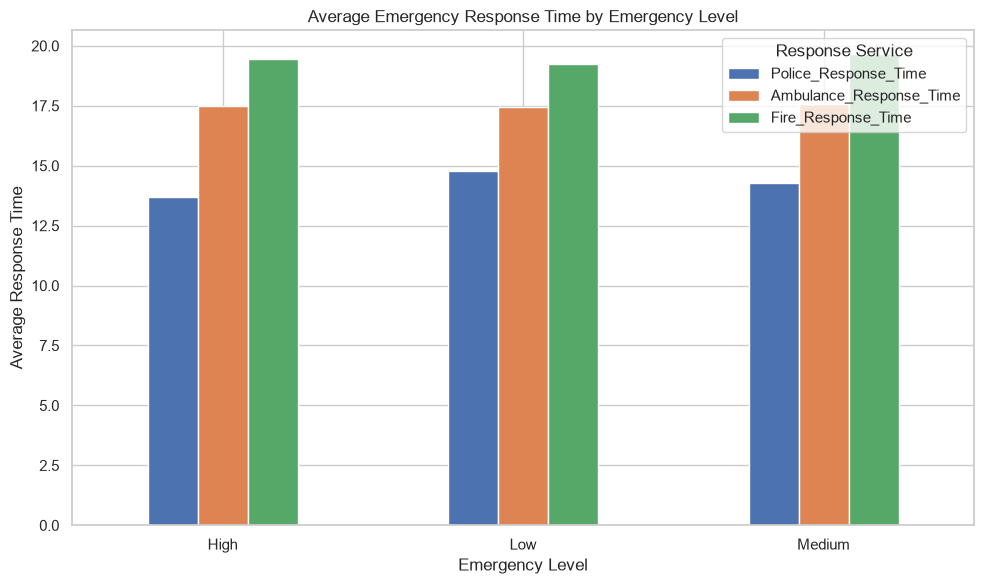

In [27]:
response_by_level = df.groupby(
    "Emergency_Level"
)[response_columns].mean()

display(response_by_level.round(2))

response_by_level.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Emergency Response Time by Emergency Level")
plt.xlabel("Emergency Level")
plt.ylabel("Average Response Time")
plt.xticks(rotation=0)
plt.legend(title="Response Service")
plt.tight_layout()

plt.savefig("../visualizations/task4_response_time.png", dpi=300)
plt.show()

## 11. Crowd Risk Analysis

Crowd level is analyzed against emergency level to understand whether different crowd conditions are associated with different emergency patterns.

Emergency_Level,High,Low,Medium
Crowd_Level,,,
High,2635,166,693
Low,2465,148,644
Medium,2425,184,640


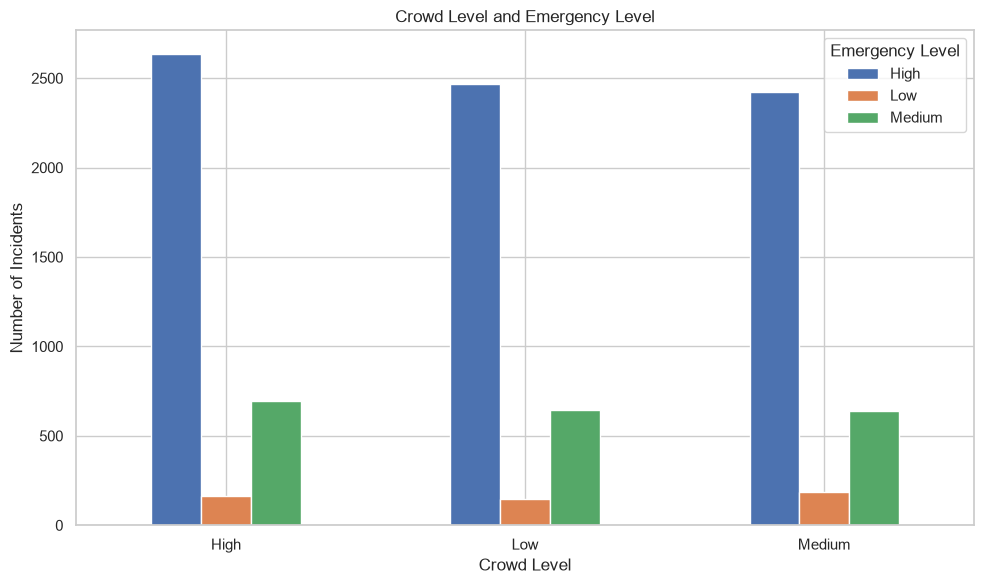

In [28]:
crowd_risk = pd.crosstab(
    df["Crowd_Level"],
    df["Emergency_Level"]
)

display(crowd_risk)

crowd_risk.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Crowd Level and Emergency Level")
plt.xlabel("Crowd Level")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Emergency Level")
plt.tight_layout()

plt.savefig("../visualizations/task4_crowd_risk.png", dpi=300)
plt.show()

## 12. Time-Based Risk Analysis

Emergency levels are analyzed across different times of the day.
This analysis can help identify periods that may require additional monitoring or emergency preparedness.

Emergency_Level,High,Low,Medium
Time_of_Day,,,
Afternoon,1888,116,472
Evening,1847,133,499
Morning,1899,139,512
Night,1891,110,494


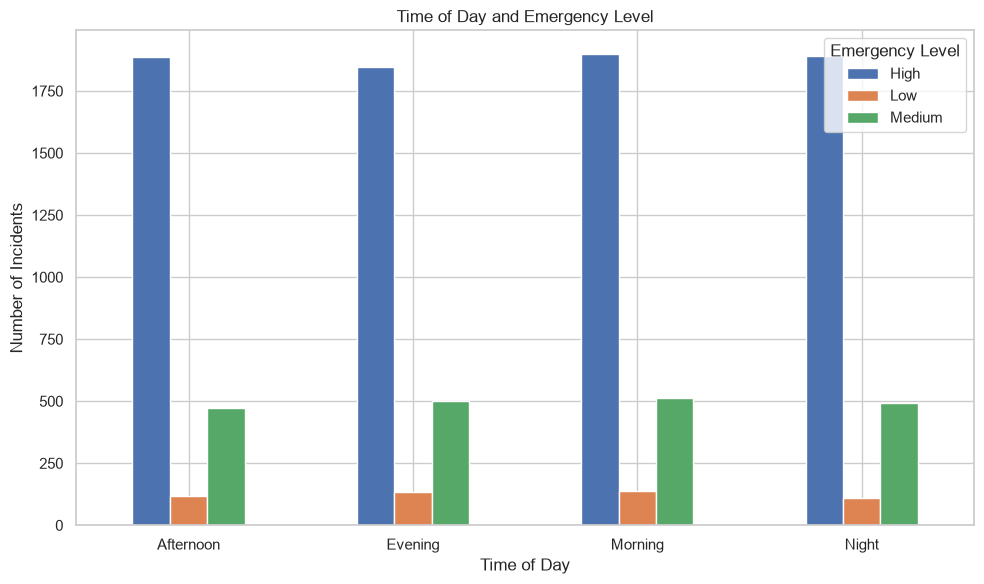

In [29]:
time_risk = pd.crosstab(
    df["Time_of_Day"],
    df["Emergency_Level"]
)

display(time_risk)

time_risk.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Time of Day and Emergency Level")
plt.xlabel("Time of Day")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Emergency Level")
plt.tight_layout()

plt.savefig("../visualizations/task4_time_risk.png", dpi=300)
plt.show()

## 13. Machine Learning Prediction

The machine learning model developed during Task 2 can be used to predict the emergency level of new incidents.
This demonstrates how exploratory insights and predictive modeling can be combined into a real-world Data Science workflow.

In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

## 14. Prepare Data for Prediction

Categorical variables are converted into numerical representations so that they can be used by the machine learning model.
Incident ID is excluded because it is only an identifier and does not provide useful predictive information.

In [31]:
model_df = df.copy()

feature_columns = [
    "Incident_Type",
    "Area",
    "Time_of_Day",
    "Day_of_Week",
    "Weather",
    "Crowd_Level",
    "CCTV_Available",
    "Police_Response_Time",
    "Ambulance_Response_Time",
    "Fire_Response_Time",
    "Number_of_People",
    "Severity_Score",
    "Previous_Incidents"
]

X = model_df[feature_columns].copy()
y = model_df["Emergency_Level"].copy()

feature_encoders = {}

for column in X.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    feature_encoders[column] = encoder

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

print("Features prepared successfully.")
print("Feature shape:", X.shape)

Features prepared successfully.
Feature shape: (10000, 13)


C:\Users\MATHUMITHA\AppData\Local\Temp\ipykernel_9580\517433415.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in X.select_dtypes(include="object").columns:


## 15. Train a Random Forest Model

A Random Forest classifier is trained on the cleaned public safety dataset.
Random Forest is suitable for this classification problem because it can model nonlinear relationships between multiple incident characteristics.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_encoder.classes_
    )
)

Random Forest Accuracy: 0.9625

Classification Report:
              precision    recall  f1-score   support

        High       0.98      0.99      0.99      1505
         Low       0.99      0.66      0.79       100
      Medium       0.89      0.92      0.91       395

    accuracy                           0.96      2000
   macro avg       0.95      0.86      0.89      2000
weighted avg       0.96      0.96      0.96      2000



## 16. Feature Importance

Feature importance is analyzed to identify which variables contribute most to the Random Forest predictions.
These results can help understand the factors that are most useful for emergency-level prediction.

,Feature,Importance
12,Previous_Incidents,0.367756
11,Severity_Score,0.319647
10,Number_of_People,0.076774
7,Police_Response_Time,0.040298
9,Fire_Response_Time,0.040021
8,Ambulance_Response_Time,0.038486
3,Day_of_Week,0.024451
1,Area,0.020190
0,Incident_Type,0.019402
2,Time_of_Day,0.017019


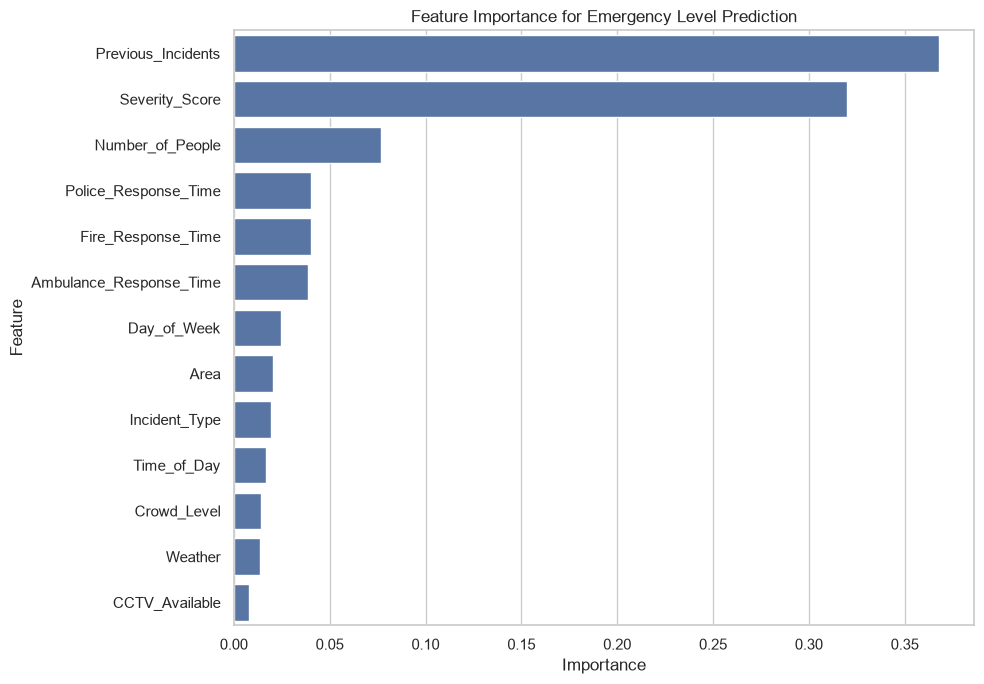

In [33]:
importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Emergency Level Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("../visualizations/task4_feature_importance.png", dpi=300)
plt.show()

## 17. Confusion Matrix

A confusion matrix is generated to evaluate how well the model distinguishes between Low, Medium, and High emergency levels.

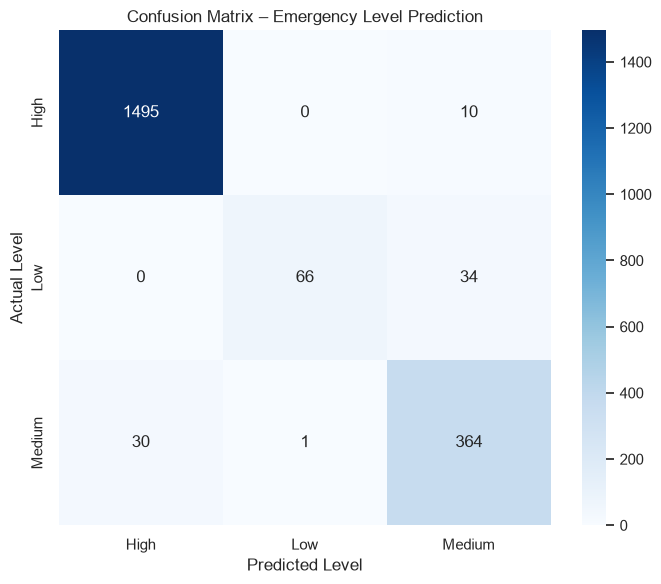

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title("Confusion Matrix – Emergency Level Prediction")
plt.xlabel("Predicted Level")
plt.ylabel("Actual Level")
plt.tight_layout()

plt.savefig("../visualizations/task4_confusion_matrix.png", dpi=300)
plt.show()

## 18. Business Recommendations

Based on the analysis, the following types of actions can be considered:

- Prioritize monitoring of areas with higher incident frequency.
- Pay closer attention to incident categories frequently associated with high emergency levels.
- Use severity information to support emergency prioritization.
- Analyze response-time patterns to identify possible operational improvements.
- Consider crowd and time-of-day patterns when planning emergency resources.
- Use machine learning predictions as decision-support information rather than as a replacement for human judgment.

## 19. Real-World Application

The developed analysis can support a Smart City Public Safety system in several ways:

1. Incident Monitoring
   - Track historical incident patterns.
2. Risk Assessment
   - Identify incident and location patterns associated with higher emergency levels.
3. Emergency Resource Planning
   - Support planning of police, ambulance, and fire-service resources.
4. Predictive Decision Support
   - Use machine learning to estimate emergency levels for new incidents.
5. Operational Analysis
   - Compare emergency response times across different incident categories and emergency levels.

The system is intended to support human decision-makers and should not replace emergency-service professionals.

## 20. Limitations

The dataset is a structured historical dataset and may not represent every real-world public safety situation.
The analysis does not directly process live CCTV footage, emergency calls, social media streams, or real-time sensor data.
Machine learning predictions should therefore be treated as decision-support information and validated using real operational data before deployment.

## 21. Conclusion

This project demonstrates an end-to-end Data Science workflow for a Smart City Public Safety use case.
The cleaned dataset was analyzed to understand emergency levels, incident types, areas, severity, response times, crowd conditions, and time-based patterns.
A Random Forest classification model was also applied to predict emergency levels and identify important predictive features.
The combination of descriptive analytics and predictive modeling demonstrates how Data Science can support public safety planning, emergency resource allocation, and data-driven decision-making.
Future development can extend the system with real-time data, advanced machine learning, NLP, deep learning, and automated emergency response capabilities.